<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/fCNN%2BSCL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [174]:
from source import *
import torchvision.models as models


In [49]:
#@title Load Data
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'data/hellchar/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Function to preprocess images (resize, binariz, normalize eand flatten)
def preprocess_image(image_path, size=(64, 64)):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    # Flatten and return
    return img_normalized.flatten()

# Preprocess all images
image_data = []
for img_file in image_files:
    try:
        processed_img = preprocess_image(img_file)
        image_data.append(processed_img)
    except Exception as e:
        print(f"Error processing image {img_file}: {e}")

image_data = np.array(image_data)

# Adding metadata
filenames = os.listdir('data/hellchar/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])

metadata = pd.read_csv('data/hellchar/hellchar.csv')

data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [85]:
# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array

# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# %%
# @title Data Splitting and Dataset Creation
# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)

# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

In [50]:
#@title Preprocess
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

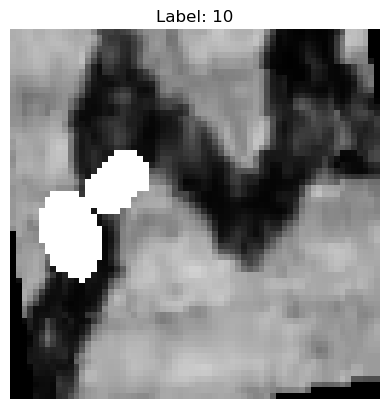

In [32]:
#@title Show a random training sample
images, labels = next(iter(train_loader_2d_aug))
idx = random.randint(0, images.size(0)-1)
img = images[idx].squeeze().numpy()  # remove channel dim if grayscale
label = labels[idx].item()
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

## Train fCNN+SCL


In [87]:
num_classes_2d = len(label_encoder.classes_)
image_input_size = (64, 64)  # Match preprocess_image_2d size
model = CNN2D(num_classes=num_classes_2d, image_size=image_input_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Move model to the device

CNN2D(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=24, bias=True)
)

In [47]:
# Train the fCNN+SCL

train_losses, val_losses, val_accs = train_cnn2d(
    model, train_loader_2d_aug, val_loader_2d, device, num_classes_2d,
    use_swscl=True, use_tta=True, tta_transform=tta_transform,
    similarity_matrix_fn=custom_similarity_matrix
)

Epoch [1/100] Train Loss: 2.6908, Val Loss: 1.2999, Val Accuracy: 0.5845
Epoch [2/100] Train Loss: 2.1415, Val Loss: 1.1047, Val Accuracy: 0.6622
Epoch [3/100] Train Loss: 1.9514, Val Loss: 0.9670, Val Accuracy: 0.6852
Epoch [4/100] Train Loss: 1.5810, Val Loss: 0.8622, Val Accuracy: 0.7255
Epoch [5/100] Train Loss: 1.7518, Val Loss: 0.8998, Val Accuracy: 0.7006
Epoch [6/100] Train Loss: 1.7040, Val Loss: 0.7741, Val Accuracy: 0.7553
Epoch [7/100] Train Loss: 1.4008, Val Loss: 0.7707, Val Accuracy: 0.7582
Epoch [8/100] Train Loss: 1.6430, Val Loss: 0.7736, Val Accuracy: 0.7399
Epoch [9/100] Train Loss: 1.5911, Val Loss: 0.7538, Val Accuracy: 0.7630
Epoch [10/100] Train Loss: 1.3036, Val Loss: 0.7666, Val Accuracy: 0.7428
Epoch [11/100] Train Loss: 1.5500, Val Loss: 0.7470, Val Accuracy: 0.7562
Epoch [12/100] Train Loss: 1.5426, Val Loss: 0.7527, Val Accuracy: 0.7447
Epoch [13/100] Train Loss: 1.2253, Val Loss: 0.7775, Val Accuracy: 0.7466
Epoch [14/100] Train Loss: 1.4843, Val Loss: 0.

              precision    recall  f1-score   support

       Alpha       0.67      0.40      0.50       139
        Beta       0.70      0.85      0.77        67
         Chi       0.84      0.98      0.90        85
       Delta       0.94      0.81      0.87       113
     Epsilon       0.78      0.87      0.82       138
         Eta       0.75      0.81      0.78       124
       Gamma       0.77      0.78      0.78       105
        Iota       0.72      0.82      0.77       141
       Kappa       0.87      0.86      0.87       127
      Lambda       0.57      0.85      0.68       117
          Mu       0.80      0.82      0.81       126
          Nu       0.83      0.86      0.84       134
       Omega       0.89      0.93      0.91       126
     Omicron       0.74      0.79      0.77       136
         Phi       0.86      0.83      0.85        83
          Pi       0.82      0.77      0.79       127
         Psi       0.91      0.59      0.71        17
         Rho       0.87    

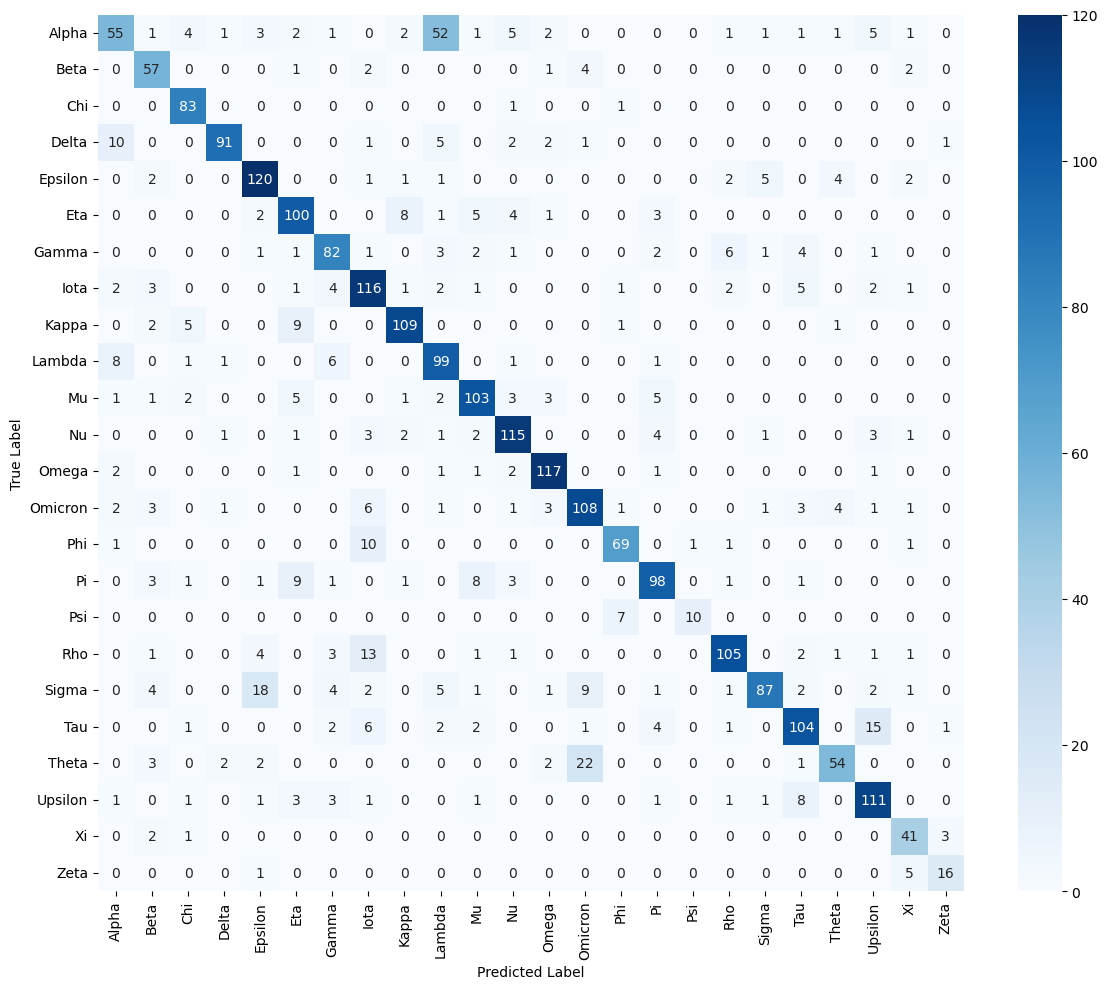

In [165]:
# Load the best model state for inference
model.load_state_dict(torch.load('best_CNN_supcon_model.pth', map_location=torch.device('cpu')))
evaluate(model, test_loader_2d, device, label_encoder)

In [34]:
#@title Visualise the learnt similarity matrix of the prototypes
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

def compute_class_prototypes(model, dataloader, device):
    model.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            feats = model.get_embeddings(x)
            embeddings.append(feats.cpu())
            labels.append(y)

    embeddings = torch.cat(embeddings, dim=0)
    labels = torch.cat(labels, dim=0)

    prototypes = []
    for c in torch.unique(labels):
        mask = (labels == c)
        proto = embeddings[mask].mean(dim=0)
        prototypes.append(proto)

    return torch.stack(prototypes)

def compute_similarity_matrix(prototypes):
    # cosine similarity between all class prototypes
    sim = F.cosine_similarity(
        prototypes.unsqueeze(1),  # (C,1,D)
        prototypes.unsqueeze(0),  # (1,C,D)
        dim=-1
    )
    return sim

def plot_similarity_matrix(S, class_names=None, title="S_dynamic"):
    plt.figure(figsize=(8,6))
    sns.heatmap(S.cpu().numpy(), annot=False, cmap="viridis",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.show()



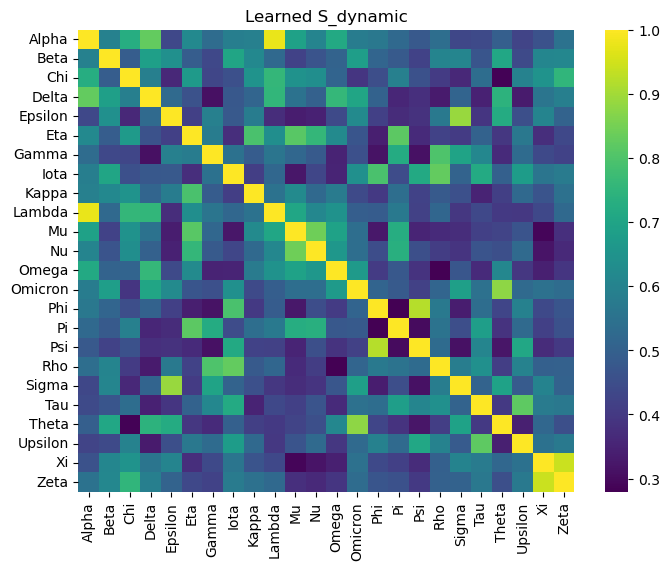

In [172]:
# Usage after training
prototypes = compute_class_prototypes(model, train_loader_2d_aug, device)
S_dynamic = compute_similarity_matrix(prototypes)
plot_similarity_matrix(S_dynamic, class_names=label_encoder.classes_, title="Learned S_dynamic")

## Evaluate resnet18

In [57]:
import torchvision.models as models

In [59]:
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(ResNetClassifier, self).__init__()
        self.resnet = models.resnet18(pretrained=pretrained)

        # Modify first conv layer for grayscale input
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace final layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)

        # Get embeddings from the first part of fc layer
        x = self.resnet.fc[0](x)  # Dropout
        x = self.resnet.fc[1](x)  # Linear to 512
        x = self.resnet.fc[2](x)  # ReLU
        return x

In [167]:
model_resnet_advanced = ResNetClassifier(num_classes=24, pretrained=True)
model_resnet_advanced.load_state_dict(torch.load('best_resnet_supcon_model.pth', map_location=torch.device('cpu')))

/opt/anaconda3/envs/vesuvius_clustering/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/vesuvius_clustering/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [65]:
device = torch.device('cpu')

              precision    recall  f1-score   support

       Alpha       0.73      0.43      0.54       139
        Beta       0.92      0.70      0.80        67
         Chi       0.96      0.92      0.94        85
       Delta       0.88      0.86      0.87       113
     Epsilon       0.85      0.93      0.89       138
         Eta       0.84      0.84      0.84       124
       Gamma       0.73      0.76      0.74       105
        Iota       0.85      0.74      0.79       141
       Kappa       0.94      0.93      0.94       127
      Lambda       0.70      0.66      0.68       117
          Mu       0.87      0.80      0.83       126
          Nu       0.88      0.84      0.86       134
       Omega       0.63      0.98      0.76       126
     Omicron       0.72      0.90      0.80       136
         Phi       0.76      0.96      0.85        83
          Pi       0.84      0.83      0.84       127
         Psi       1.00      0.47      0.64        17
         Rho       0.95    

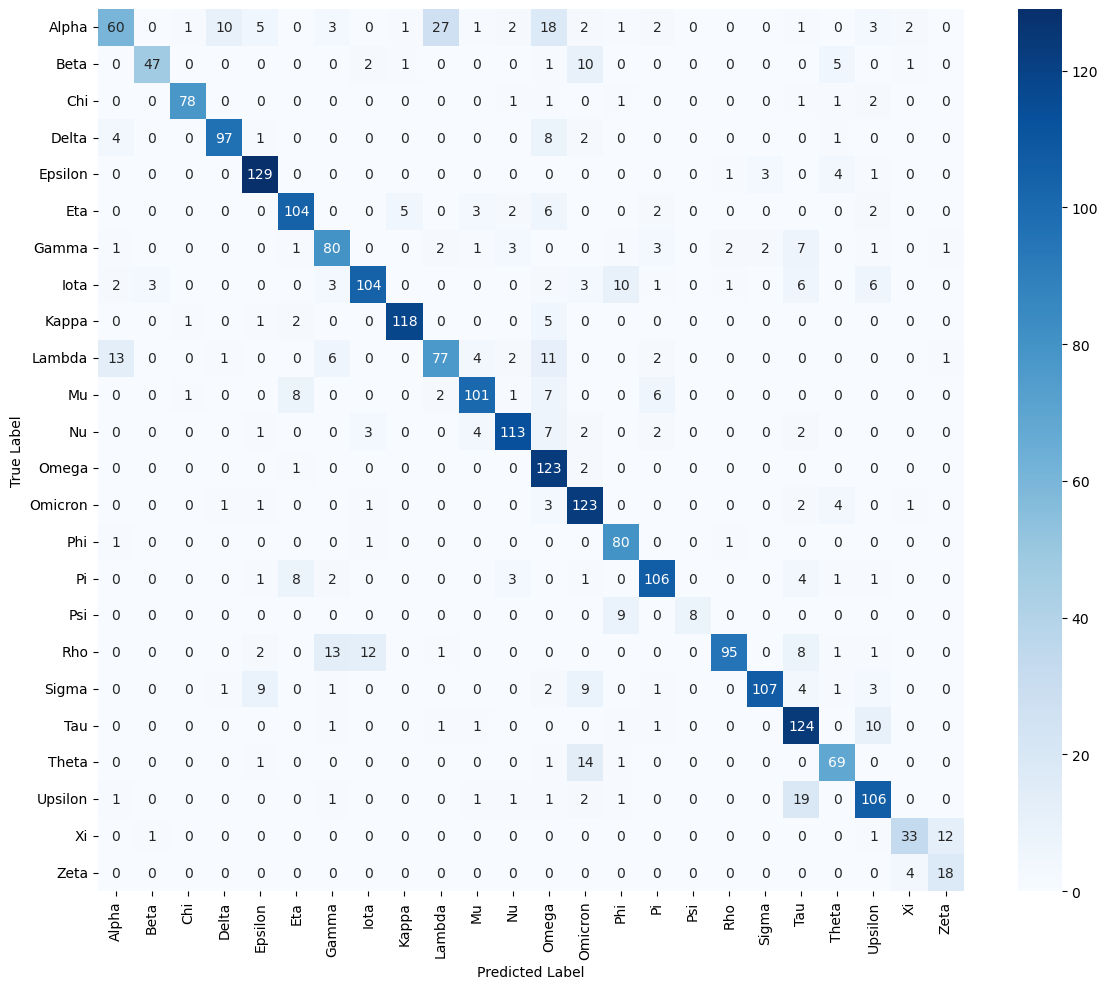

In [169]:
evaluate(model_resnet_advanced, test_loader_2d, device, label_encoder)

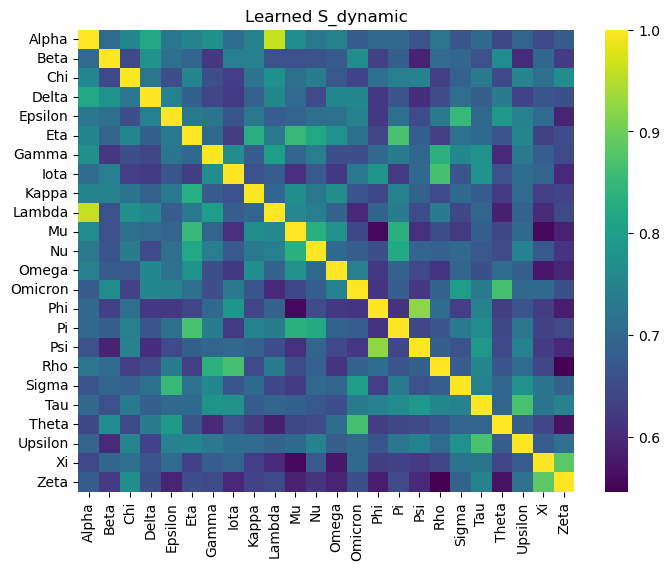

In [41]:
# Usage after training
prototypes = compute_class_prototypes(model_resnet_advanced, train_loader_2d_aug, device)
S_dynamic = compute_similarity_matrix(prototypes)
plot_similarity_matrix(S_dynamic, class_names=label_encoder.classes_, title="Learned S_dynamic")

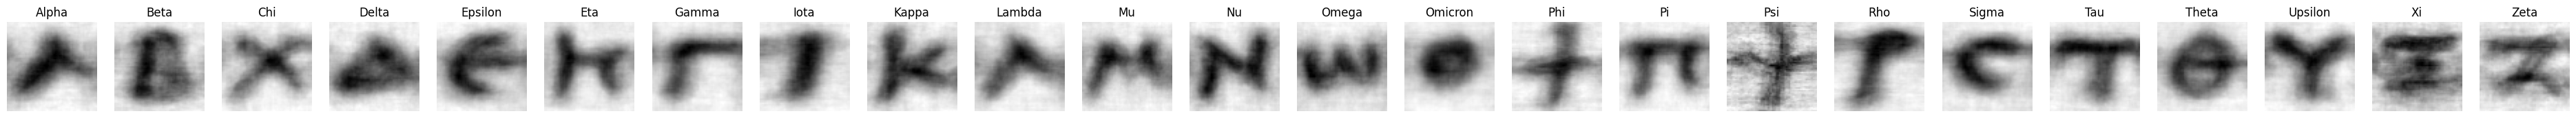

In [49]:
#@title Visualisation of prototypes

import matplotlib.pyplot as plt

def compute_image_prototypes(dataloader, device):
    images, labels = [], []
    for x, y in dataloader:
        images.append(x.cpu())
        labels.append(y)
    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)

    prototypes = []
    for c in torch.unique(labels):
        mask = (labels == c)
        proto_img = images[mask].mean(dim=0)  # average image
        prototypes.append(proto_img)

    return torch.stack(prototypes)

def plot_image_prototypes(proto_images, class_names=None):
    n_classes = proto_images.size(0)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))
    for i in range(n_classes):
        ax = axes[i]
        ax.imshow(proto_images[i].squeeze(), cmap="gray")
        if class_names is not None:
            ax.set_title(class_names[i])
        ax.axis("off")
    plt.show()

# Usage
proto_images = compute_image_prototypes(test_loader_2d, device)
plot_image_prototypes(proto_images, class_names=label_encoder.classes_)

## Run fCNN+SCL and Expert Priors


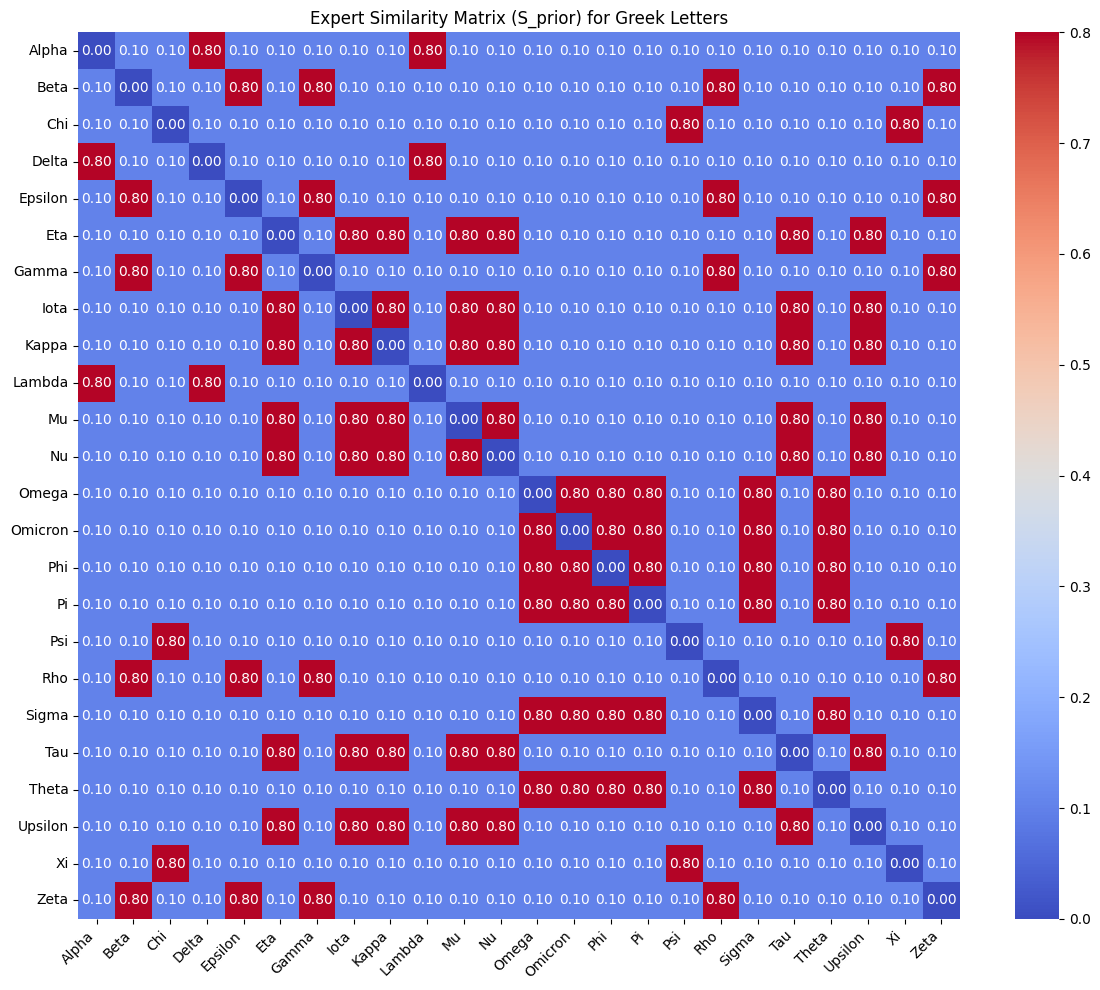

In [7]:
#@title The Expert Priors
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Groupings (from previous step)
letter_groups = {
    "straight_lines": ['Iota', 'Eta', 'Tau', 'Lambda', 'Mu', 'Nu', 'Upsilon', 'Kappa'],
    "triangles": ['Delta', 'Lambda', 'Alpha'],
    "curves": ['Omicron', 'Omega', 'Phi', 'Pi', 'Theta', 'Sigma'],
    "loops": ['Beta', 'Epsilon', 'Gamma', 'Zeta', 'Rho'],
    "complex": ['Psi', 'Xi', 'Chi']
}

group_names = list(letter_groups.keys())
group_to_labels = {g: set(letter_groups[g]) for g in group_names}

# Map class name to group index
label_to_group = {}
for g, labels in group_to_labels.items():
    for l in labels:
        label_to_group[l] = g

class_names = label_encoder.classes_
num_classes = len(class_names)

# Initialize S_prior
S_prior = np.zeros((num_classes, num_classes), dtype=np.float32)

# Fill S_prior: high similarity within same group, low between groups
high_sim = 0.8
low_sim = 0.1

for i, ci in enumerate(class_names):
    for j, cj in enumerate(class_names):
        if i == j:
            S_prior[i,j] = 0.0  # diagonal = 0
        elif label_to_group[ci] == label_to_group[cj]:
            S_prior[i,j] = high_sim
        else:
            S_prior[i,j] = low_sim

# Convert to torch tensor
S_prior = torch.tensor(S_prior, dtype=torch.float32)

plt.figure(figsize=(12,10))
sns.heatmap(S_prior.numpy(),
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap="coolwarm",
            annot=True, fmt=".2f", cbar=True)

plt.title("Expert Similarity Matrix (S_prior) for Greek Letters")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()